# Task 1

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
import pandas as pd
data = fetch_california_housing()
x = data.data
y = data.target
print(x.shape)
print(y.shape)

(20640, 8)
(20640,)


In [4]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df["MedHouseVal"] = data.target
print(df.head(7))

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
5  4.0368      52.0  4.761658   1.103627       413.0  2.139896     37.85   
6  3.6591      52.0  4.931907   0.951362      1094.0  2.128405     37.84   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
5    -122.25        2.697  
6    -122.25        2.992  


In [57]:
np.random.seed(9432)
indices=np.random.permutation(len(x))
X=x[indices]
y=y[indices]

In [58]:
n=len(X)
train_end=int(0.60*n)
val_end=int(0.80*n)
X_train=X[:train_end]
y_train=y[:train_end]
X_val=X[train_end:val_end]
y_val=y[train_end:val_end]
X_test=X[val_end:]
y_test=y[val_end:]

In [61]:
X_mean=np.mean(X_train,axis=0)
X_std=np.std(X_train,axis=0)
print("Training Mean", X_mean)
print("\nTraining Std", X_std)

Training Mean [ 3.85596161e+00  2.86526970e+01  5.42962223e+00  1.09884519e+00
  1.41660021e+03  3.03186757e+00  3.56333664e+01 -1.19564612e+02]

Training Std [1.90801811e+00 1.25882840e+01 2.43426411e+00 4.93702962e-01
 1.07508341e+03 7.10895963e+00 2.14535603e+00 2.00656429e+00]


In [62]:
X_train_norm=(X_train-X_mean)/X_std
X_val_norm=(X_val-X_mean)/X_std
X_test_norm=(X_test-X_mean)/X_std

In [46]:
X_train_aug=np.hstack([
    np.ones((X_train_norm.shape[0],1)),
    X_train_norm
])

X_val_aug=np.hstack([
    np.ones((X_val_norm.shape[0],1)),
    X_val_norm
])

X_test_aug=np.hstack([
    np.ones((X_test_norm.shape[0],1)),
    X_test_norm
])

In [63]:
y_mean=np.mean(y_train)
y_std=np.std(y_train)

In [64]:
y_train_std=(y_train-y_mean)/y_std
y_val_std=(y_val-y_mean)/y_std
y_test_std=(y_test-y_mean)/y_std

In [65]:
print("X_train_aug:", X_train_aug.shape)
print("y_train_std:", y_train_std.shape)

print("X_val_aug:", X_val_aug.shape)
print("y_val_std:", y_val_std.shape)

print("X_test_aug:", X_test_aug.shape)
print("y_test_std:", y_test_std.shape)

X_train_aug: (12384, 9)
y_train_std: (12384,)
X_val_aug: (4128, 9)
y_val_std: (4128,)
X_test_aug: (4128, 9)
y_test_std: (4128,)


# Task 2

In [66]:
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

In [67]:
# Task 2: Mini-Batch Gradient Descent

def mini_batch_gradient_descent(
    X_train,
    y_train,
    X_val,
    y_val,
    learning_rate,
    batch_size,
    max_epochs=1000,
    patience=100
):

    n_samples = X_train.shape[0]
    n_features = X_train.shape[1]

    weights = np.zeros(n_features)

    train_losses = []
    val_losses = []

    best_weights = weights.copy()
    best_val_loss = np.inf
    best_epoch = 0

    epochs_without_improvement = 0

    for epoch in range(1, max_epochs + 1):

        indices = np.random.permutation(n_samples)

        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]

        total_loss = 0.0
        total_samples = 0

        for start in range(0, n_samples, batch_size):

            end = min(start + batch_size, n_samples)

            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            current_batch_size = X_batch.shape[0]

            y_pred = X_batch @ weights

            error = y_pred - y_batch

            batch_loss = np.mean(error ** 2)

            total_loss += batch_loss * current_batch_size
            total_samples += current_batch_size

            gradient = (
                (2 / current_batch_size)
                * (X_batch.T @ error)
            )

            weights = weights - learning_rate * gradient

        epoch_train_loss = total_loss / total_samples

        y_val_pred = X_val @ weights

        epoch_val_loss = mse_loss(
            y_val,
            y_val_pred
        )

        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)

        if epoch_val_loss < best_val_loss:

            best_val_loss = epoch_val_loss
            best_weights = weights.copy()
            best_epoch = epoch

            epochs_without_improvement = 0

        else:

            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    return (
        best_weights,
        train_losses,
        val_losses,
        best_epoch,
        best_val_loss
    )

# Task 3

In [68]:
learning_rates = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10]

lr_results = {}

for lr in learning_rates:
    print("Learning rate:", lr)
    print()

    (
        best_weights,
        train_losses,
        val_losses,
        best_epoch,
        best_val_loss
    ) = mini_batch_gradient_descent(
        X_train_aug,
        y_train_std,
        X_val_aug,
        y_val_std,
        learning_rate=lr,
        batch_size=128
    )

    lr_results[lr] = {
        "weights": best_weights,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss
    }

    print("Best epoch:", best_epoch)
    print("Best validation MSE:", best_val_loss)
    print()

Learning rate: 1e-05

Best epoch: 1000
Best validation MSE: 0.47149367281707794

Learning rate: 0.0001

Best epoch: 1000
Best validation MSE: 0.39683615405704475

Learning rate: 0.001

Best epoch: 307
Best validation MSE: 0.3916867972276237

Learning rate: 0.01

Best epoch: 26
Best validation MSE: 0.3904515945896926

Learning rate: 0.1



C:\Users\Dell\AppData\Local\Temp\ipykernel_29456\2921494777.py:2: RuntimeWarning: overflow encountered in square
  return np.mean((y_true - y_pred) ** 2)
C:\Users\Dell\AppData\Local\Temp\ipykernel_29456\2969188111.py:51: RuntimeWarning: overflow encountered in square
  batch_loss = np.mean(error ** 2)
c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\Dell\AppData\Local\Temp\ipykernel_29456\2969188111.py:53: RuntimeWarning: overflow encountered in scalar add
  total_loss += batch_loss * current_batch_size
C:\Users\Dell\AppData\Local\Temp\ipykernel_29456\2969188111.py:58: RuntimeWarning: overflow encountered in matmul
  * (X_batch.T @ error)
C:\Users\Dell\AppData\Local\Temp\ipykernel_29456\2969188111.py:47: RuntimeWarning: invalid value encountered in matmul
  y_pred = X_batch @ weights
C:\Users\Dell\AppData\Local\Temp\ip

Best epoch: 1
Best validation MSE: 101.94285939564816

Learning rate: 1

Best epoch: 1
Best validation MSE: 1.4682908766924138e+89

Learning rate: 10

Best epoch: 0
Best validation MSE: inf



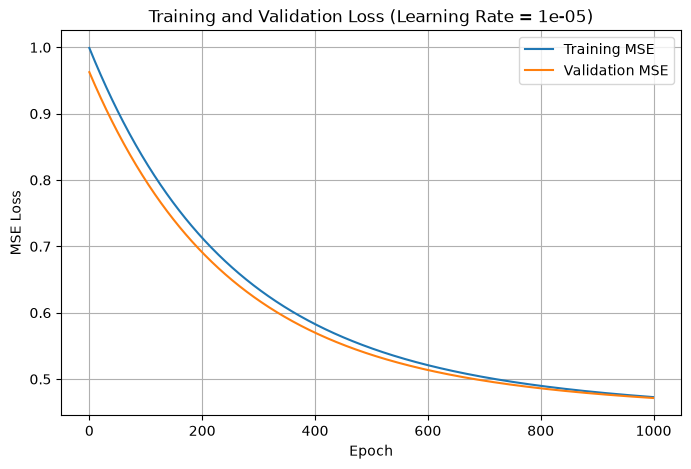

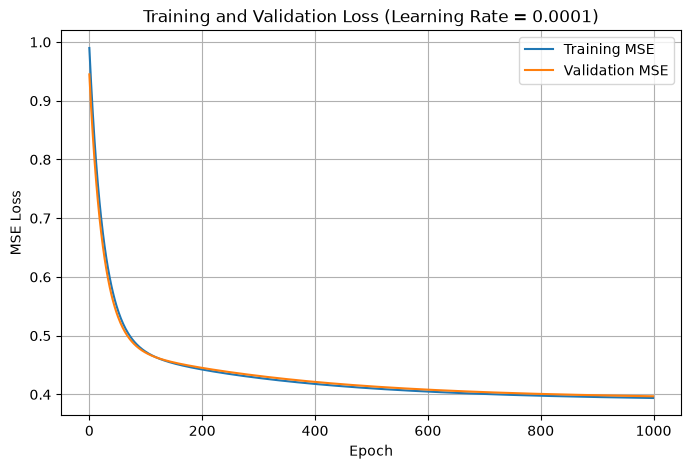

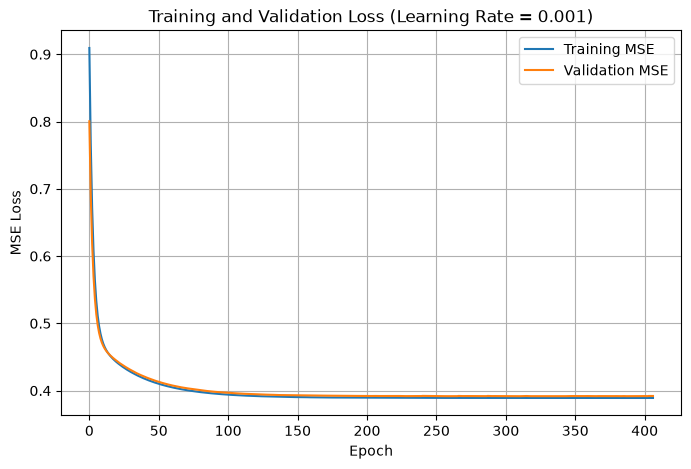

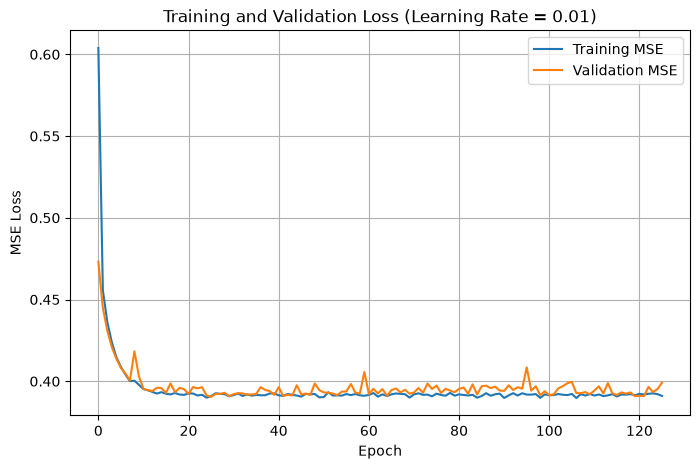

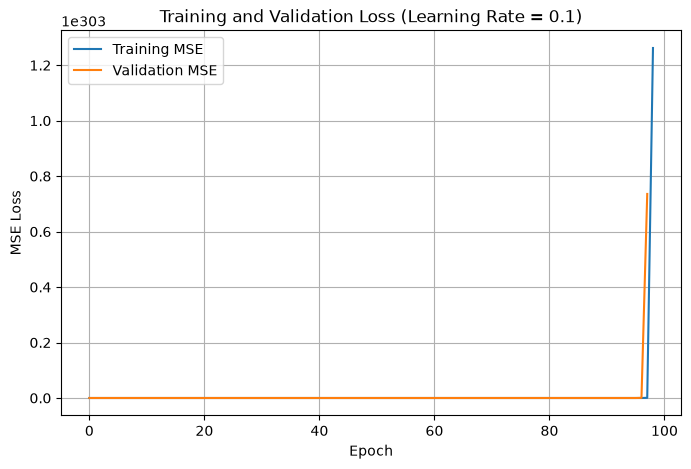

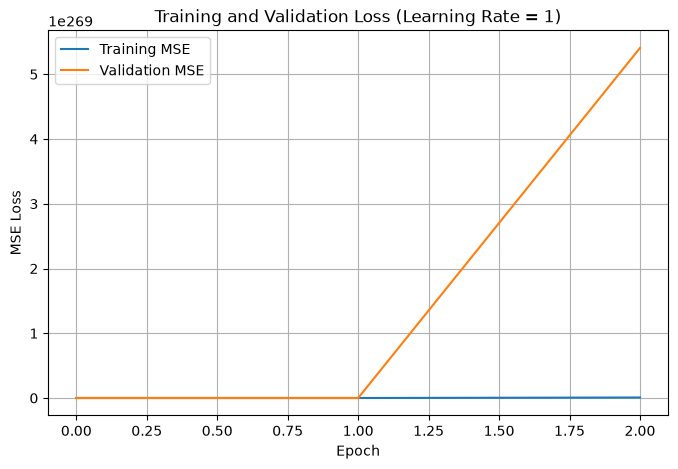

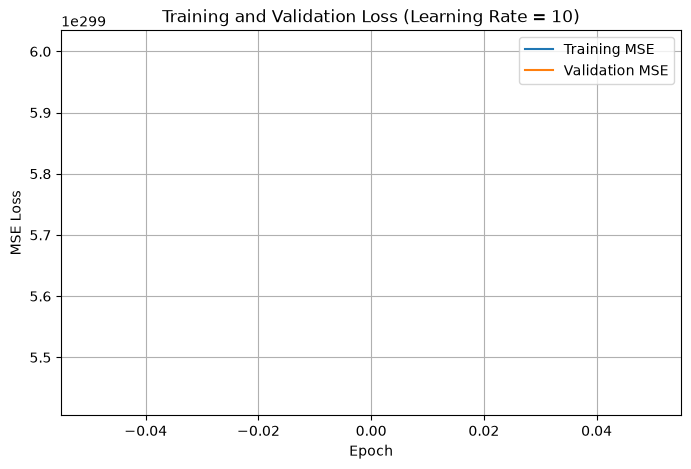

In [69]:
for lr in learning_rates:

    result = lr_results[lr]

    plt.figure(figsize=(8, 5))

    plt.plot(
        result["train_losses"],
        label="Training MSE"
    )

    plt.plot(
        result["val_losses"],
        label="Validation MSE"
    )

    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")

    plt.title(
        f"Training and Validation Loss (Learning Rate = {lr})"
    )

    plt.legend()
    plt.grid(True)

    plt.show()

In [70]:
best_lr=min(lr_results,
            key=lambda lr: lr_results[lr]["best_val_loss"]
           )
print("best learning rate:", best_lr)
print("Best Validation MSE:", lr_results[best_lr]["best_val_loss"])

best learning rate: 0.01
Best Validation MSE: 0.3904515945896926


# Task 4

In [74]:
batch_sizes=[1,16,32,64,128,256,len(X_train_aug)]
batch_results={}
for batch_size in batch_sizes:
    print("Batch size:" ,batch_size)
    print("\n")
    (best_weights,train_losses,val_losses,best_epoch,best_val_loss)=mini_batch_gradient_descent(X_train_aug,y_train_std,X_val_aug,y_val_std,learning_rate=best_lr,batch_size=batch_size)
    batch_results[batch_size] = {
        "weights": best_weights,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss
    }

    print("Best epoch:", best_epoch)
    print("Best validation MSE:", best_val_loss)

Batch size: 1




C:\Users\Dell\AppData\Local\Temp\ipykernel_29456\2969188111.py:53: RuntimeWarning: overflow encountered in scalar add
  total_loss += batch_loss * current_batch_size
C:\Users\Dell\AppData\Local\Temp\ipykernel_29456\2969188111.py:51: RuntimeWarning: overflow encountered in square
  batch_loss = np.mean(error ** 2)
C:\Users\Dell\AppData\Local\Temp\ipykernel_29456\2921494777.py:2: RuntimeWarning: overflow encountered in square
  return np.mean((y_true - y_pred) ** 2)


Best epoch: 1
Best validation MSE: 725835.1554681169
Batch size: 16


Best epoch: 1
Best validation MSE: 92.30425979815455
Batch size: 32


Best epoch: 1
Best validation MSE: 2.875593498417308
Batch size: 64


Best epoch: 33
Best validation MSE: 0.3903332959325794
Batch size: 128


Best epoch: 108
Best validation MSE: 0.3903911270249129
Batch size: 256


Best epoch: 126
Best validation MSE: 0.3907096946584178
Batch size: 12384


Best epoch: 1000
Best validation MSE: 0.39639576933149456


In [73]:
print(
    f"{'Batch Size':<20}"
    f"{'Lowest Validation MSE':<25}"
    f"{'Best Epoch'}"
)

print("-" * 60)

for batch_size in batch_sizes:

    result = batch_results[batch_size]

    batch_name = (
        "Entire Training Dataset"
        if batch_size == len(X_train_aug)
        else str(batch_size)
    )

    print(
        f"{batch_name:<20}"
        f"{result['best_val_loss']:<25.6f}"
        f"{result['best_epoch']}"
    )

Batch Size          Lowest Validation MSE    Best Epoch
------------------------------------------------------------
1                   3229.059845              1
16                  2.594721                 1
32                  1.816308                 1
64                  0.390627                 31
128                 0.390713                 125
256                 0.390834                 133
Entire Training Dataset0.396396                 1000


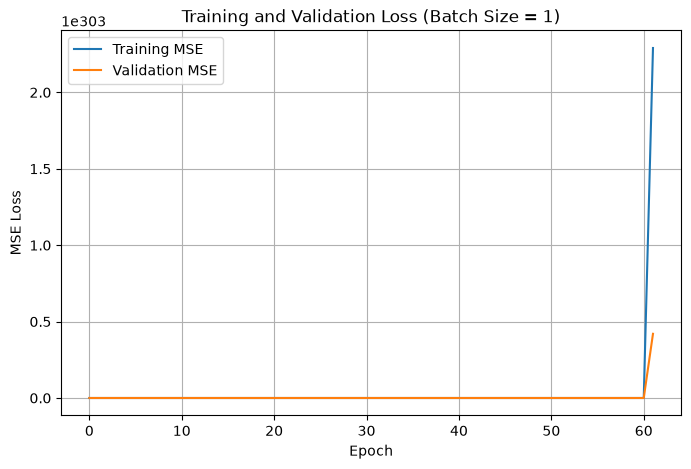

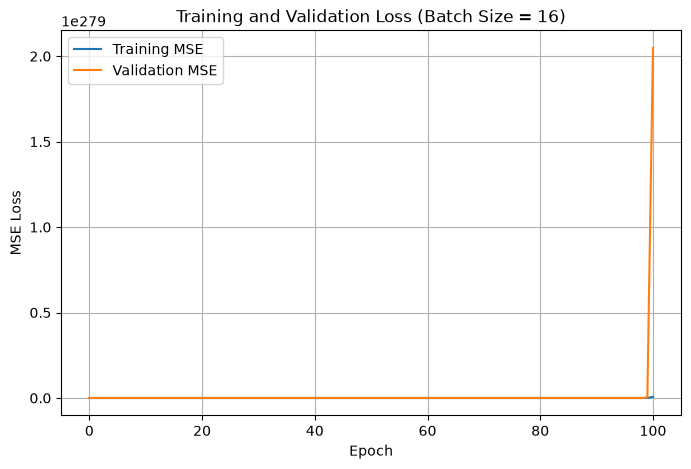

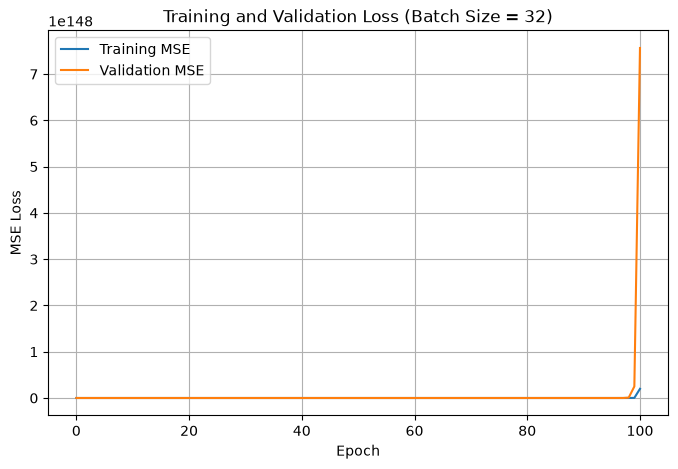

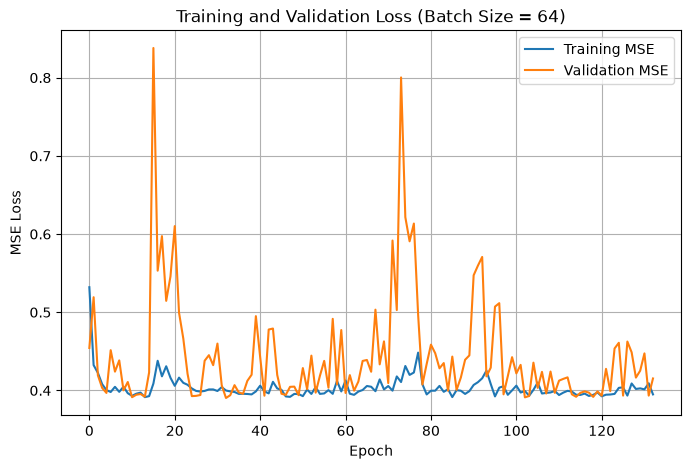

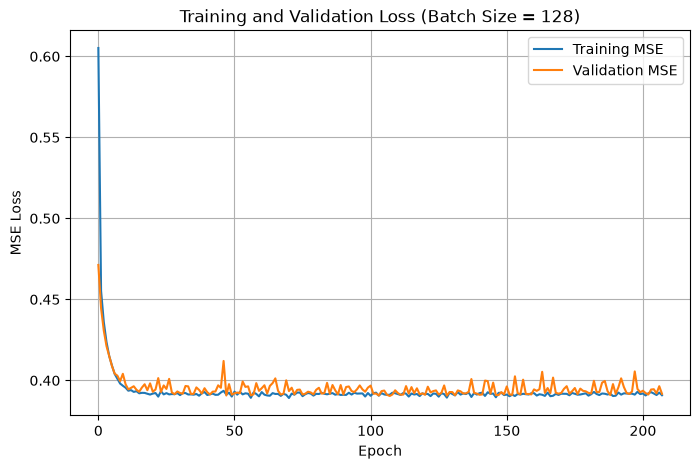

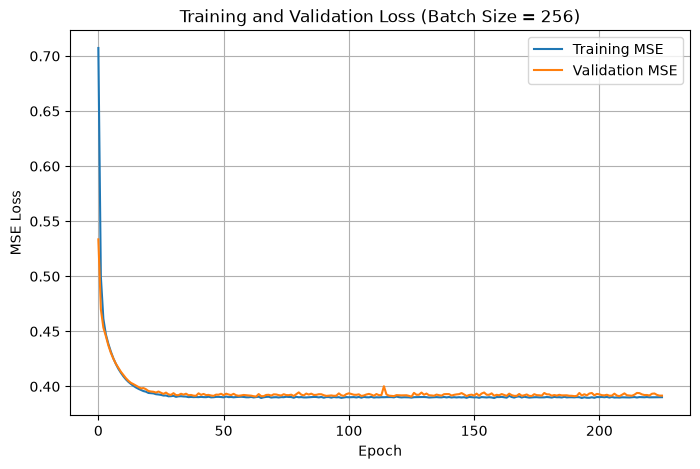

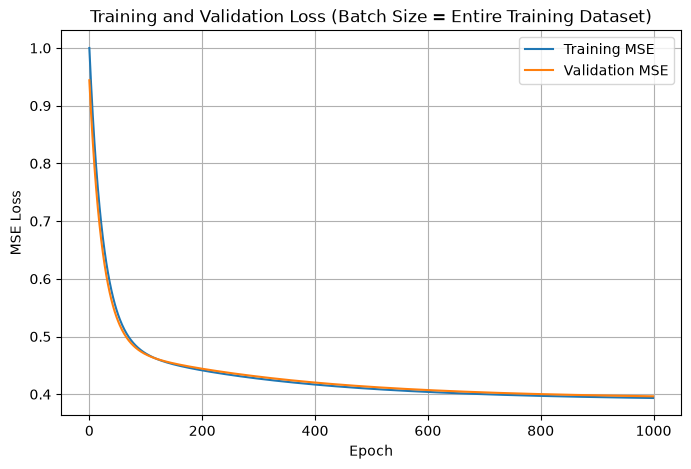

In [75]:
for batch_size in batch_sizes:

    result = batch_results[batch_size]

    if batch_size == len(X_train_aug):
        title_batch = "Entire Training Dataset"
    else:
        title_batch = str(batch_size)

    plt.figure(figsize=(8, 5))

    plt.plot(
        result["train_losses"],
        label="Training MSE"
    )

    plt.plot(
        result["val_losses"],
        label="Validation MSE"
    )

    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")

    plt.title(
        f"Training and Validation Loss "
        f"(Batch Size = {title_batch})"
    )

    plt.legend()
    plt.grid(True)

    plt.show()

In [76]:
best_batch_size = min(
    batch_results,
    key=lambda batch_size:
        batch_results[batch_size]["best_val_loss"]
)

print("Best batch size:", best_batch_size)

print(
    "Best validation MSE:",
    batch_results[best_batch_size]["best_val_loss"]
)

Best batch size: 64
Best validation MSE: 0.3903332959325794


# Task 5

In [80]:
# Select the final model using the best batch size

best_batch_size = min(
    batch_results,
    key=lambda b: batch_results[b]["best_val_loss"]
)

final_model = batch_results[best_batch_size]["weights"]

print("Best batch size:", best_batch_size)
print("Final model shape:", final_model.shape)

Best batch size: 64
Final model shape: (9,)


In [77]:
inal_model = batch_results[best_batch_size]["weights"]

In [81]:
y_train_pred_std = X_train_aug @ final_model
y_val_pred_std = X_val_aug @ final_model
y_test_pred_std = X_test_aug @ final_model

In [82]:
y_train_pred = y_train_pred_std * y_std + y_mean
y_val_pred = y_val_pred_std * y_std + y_mean
y_test_pred = y_test_pred_std * y_std + y_mean

In [83]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

In [84]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

In [85]:
def mape(y_true, y_pred):
    epsilon = 1e-10

    return np.mean(
        np.abs(
            (y_true - y_pred) /
            (y_true + epsilon)
        )
    ) * 100

In [86]:
def r_squared(y_true, y_pred):

    ss_res = np.sum(
        (y_true - y_pred) ** 2
    )

    ss_tot = np.sum(
        (y_true - np.mean(y_true)) ** 2
    )

    return 1 - (ss_res / ss_tot)

In [87]:
train_rmse = rmse(y_train, y_train_pred)
val_rmse = rmse(y_val, y_val_pred)
test_rmse = rmse(y_test, y_test_pred)

train_mae = mae(y_train, y_train_pred)
val_mae = mae(y_val, y_val_pred)
test_mae = mae(y_test, y_test_pred)

train_mape = mape(y_train, y_train_pred)
val_mape = mape(y_val, y_val_pred)
test_mape = mape(y_test, y_test_pred)

train_r2 = r_squared(y_train, y_train_pred)
val_r2 = r_squared(y_val, y_val_pred)
test_r2 = r_squared(y_test, y_test_pred)

In [88]:
print(
    f"{'Dataset':<15}"
    f"{'RMSE':<15}"
    f"{'MAPE (%)':<15}"
    f"{'MAE':<15}"
    f"{'R²':<15}"
)

print("-" * 75)

print(
    f"{'Training':<15}"
    f"{train_rmse:<15.4f}"
    f"{train_mape:<15.4f}"
    f"{train_mae:<15.4f}"
    f"{train_r2:<15.4f}"
)

print(
    f"{'Validation':<15}"
    f"{val_rmse:<15.4f}"
    f"{val_mape:<15.4f}"
    f"{val_mae:<15.4f}"
    f"{val_r2:<15.4f}"
)

print(
    f"{'Test':<15}"
    f"{test_rmse:<15.4f}"
    f"{test_mape:<15.4f}"
    f"{test_mae:<15.4f}"
    f"{test_r2:<15.4f}"
)

Dataset        RMSE           MAPE (%)       MAE            R²             
---------------------------------------------------------------------------
Training       0.7230         31.7310        0.5294         0.6098         
Validation     0.7231         31.5775        0.5343         0.5953         
Test           0.7312         31.4392        0.5335         0.6027         


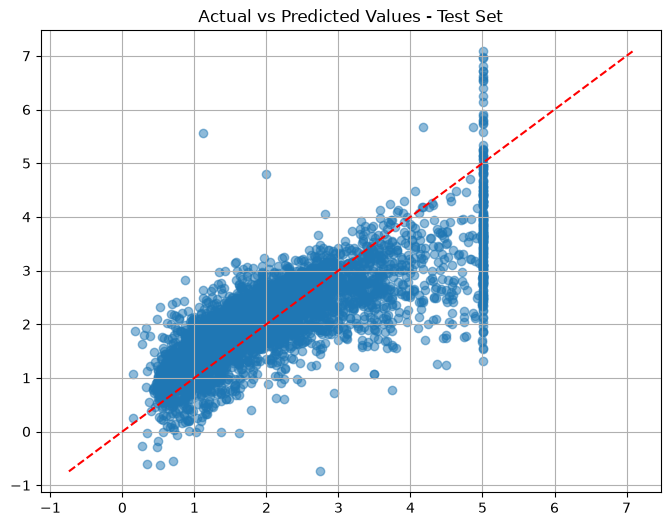

In [89]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.5
)

# Perfect prediction line
min_value = min(
    np.min(y_test),
    np.min(y_test_pred)
)

max_value = max(
    np.max(y_test),
    np.max(y_test_pred)
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    "r--"
)

plt.title("Actual vs Predicted Values - Test Set")

plt.grid(True)

plt.show()